In [1]:
# imports
import h5py as h5
import numpy as np
import psutil

from pycorr import TwoPointCorrelationFunction, setup_logging
from colossus.cosmology import cosmology

# Setup pycorr logging to view progress
setup_logging()
psutil.Process().nice(19)

In [2]:


# define bins for s (separation) and mu (cosine of angle to line-of-sight)
s_edges = np.linspace(0.01, 150, 71+1)
mu_edges = np.linspace(0, 1, 120+1)

# path to MDPL2 halos
halo_path = '/spiff/cosweeney/simulations/MDPL2/hlists/hlist_0.83760_update.hdf5'

L_box = 1_000 # h^-1 Mpc

# ---------------------------------------------------------
# Cosmology & Redshift Setup using Colossus
# ---------------------------------------------------------
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift = 1/a - 1
H = cosmo.Hz(redshift) # Hz in physical km/s/Mpc
h = cosmo.h

with h5.File(halo_path, 'r') as hdf:

    hm_cut = hdf['mvir'][()] >= 1e13 # halo mass, h^-1 M_sun

    # Load Real Space Positions
    hpos = np.array([
        hdf['x'][()][hm_cut],
        hdf['y'][()][hm_cut], 
        hdf['z'][()][hm_cut],
    ], dtype=np.float64).T 

    # Load Z-axis Peculiar Velocities (assuming 'vel' key exists and is in km/s)
    v_z = hdf['vz'][()][hm_cut]

    # ---------------------------------------------------------
    # Apply Redshift Space Distortions (RSD) along z-axis
    # ---------------------------------------------------------
    # Multiply by h to convert H(z) to h km s^-1 Mpc^-1, matching the box units
    hpos[:, 2] += v_z * (1 + redshift) * h / H

    # Ensure positions are strictly within the periodic box boundaries after RSD shift
    hpos = np.mod(hpos, L_box)

    # ---------------------------------------------------------
    # Jackknife Setup: Divide the box into a 3D sub-grid
    # ---------------------------------------------------------
    n_jk_1d = 4 # Yields 4^3 = 64 total jackknife regions
    
    grid_idx = (hpos / L_box * n_jk_1d).astype(int)
    grid_idx = np.clip(grid_idx, 0, n_jk_1d - 1)
    
    # Flatten the 3D grid indices into a 1D array of region IDs
    halo_samples = grid_idx[:, 0] + n_jk_1d * grid_idx[:, 1] + (n_jk_1d**2) * grid_idx[:, 2]

    print('Computing hh correlation function xi(s, mu)...')
    
    result = TwoPointCorrelationFunction(
        mode='smu',
        edges=(s_edges, mu_edges),
        data_positions1=hpos,
        data_samples1=halo_samples,
        engine='corrfunc',
        boxsize=L_box,
        los='z',               # Line of sight remains the z-axis
        position_type='pos',
        nthreads=84,
        compute_seps_avg=False
    )


Computing hh correlation function xi(s, mu)...
[000299.24]  07-23 14:56  TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_jackknife.JackknifeNaturalTwoPointEstimator'>.
[000299.24]  07-23 14:56  TwoPointCorrelationFunction  INFO     Running auto-correlation.
[000299.24]  07-23 14:56  TwoPointCorrelationFunction  INFO     Computing two-point counts D1D2.


/home/cosweeney/miniconda3/envs/tpcf/lib/python3.10/site-packages/pycorr/twopoint_counter.py:516: UserWarning: mu edges starting at 0 is deprecated, please use symmetric binning; I am assuming np.linspace(-1.0000, 1.0000, 241)!
  warnings.warn('{} edges starting at 0 is deprecated, please use symmetric binning; I am assuming np.linspace({:.4f}, {:.4f}, {:d})!'.format(axis, -edges[-1], edges[-1], nedges))
/home/cosweeney/miniconda3/envs/tpcf/lib/python3.10/site-packages/pycorr/corrfunc.py:153: UserWarning: These arguments are not read: {'compute_seps_avg': False}
  warnings.warn('These arguments are not read: {}'.format(attrs))


[000307.09]  07-23 14:56  TwoPointCorrelationFunction  INFO     Analytically computing two-point counts R1R2.
[000307.10]  07-23 14:56  TwoPointCorrelationFunction  INFO     Correlation function computed in elapsed time 7.86 s.


In [3]:
# ---------------------------------------------------------
# Extract Quantities
# ---------------------------------------------------------
xi = result.corr 
xi_cov = result.cov()  #method='jackknife'

# Correct Jackknife extraction: Get 'delete-one' realizations
n_jk_total = n_jk_1d**3
xi_samples = np.array([result.realization(i).corr for i in range(n_jk_total)])

xi_mean = np.mean(xi_samples, axis=0)

s_cens = (s_edges[:-1] + s_edges[1:]) / 2.0
mu_cens = (mu_edges[:-1] + mu_edges[1:]) / 2.0 

In [4]:
xi_ell, xi_ell_cov = result.get_corr(ells=(0, 2, 4), return_cov=True)

In [5]:
xi_ell_cov.shape

(210, 210)

In [5]:
import pickle 

save_path = '/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/RSCFs/xi_smu_hh_pycorr_72bin.hdf5'

print('Saving results to: ' + save_path)
with h5.File(save_path, 'w') as f:
    f.create_dataset(name='xi', data=xi, dtype=np.float64)
    f.create_dataset(name='xi_ell', data=xi_ell, dtype=np.float64)
    f.create_dataset(name='xi_ell_cov', data=xi_ell_cov, dtype=np.float64)
    f.create_dataset(name='xi_samples', data=xi_samples, dtype=np.float64)
    f.create_dataset(name='xi_mean', data=xi_mean, dtype=np.float64)
    f.create_dataset(name='xi_cov', data=xi_cov, dtype=np.float64)
    f.create_dataset(name='s_cens', data=s_cens, dtype=np.float64)
    f.create_dataset(name='s_edges', data=s_edges, dtype=np.float64)
    f.create_dataset(name='mu_cens', data=mu_cens, dtype=np.float64)
    f.create_dataset(name='mu_edges', data=mu_edges, dtype=np.float64)

    pickled_result = np.void(pickle.dumps(result))
    f.create_dataset(name='result_object', data=pickled_result)

print('Done.')

Saving results to: /spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/RSCFs/xi_smu_hh_pycorr_72bin.hdf5
Done.


In [22]:
with h5.File(save_path, 'r') as f:
    # Read the byte array and deserialize it back into a pycorr object
    result = pickle.loads(f['result_object'][()].tobytes())

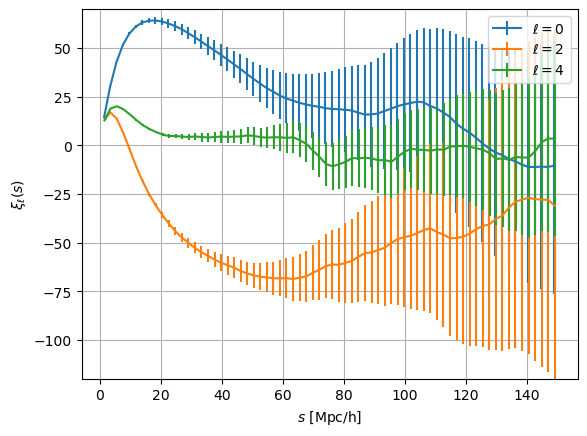

In [32]:
import matplotlib.pyplot as plt

ells = (0, 2, 4)
nells = len(ells)
# Let us rebin by 2 along first dimension (s)
#reresult = result[::2]
s, xiell, cov = result.get_corr(ells=ells, return_sep=True, return_cov=True)
std = np.array_split(np.diag(cov)**0.5, nells)
ax = plt.gca()
for ill,ell in enumerate(ells):
    ax.errorbar(s + ill * 0.1, s**2*xiell[ill], s**2*std[ill], fmt='-', label=r'$\ell = {:d}$'.format(ell))

ax.legend()
ax.grid(True)
ax.set_xlabel(r'$s$ [Mpc/h]')
ax.set_ylabel(r'$\xi_{\ell}(s)$')
plt.ylim((-120, 70))
plt.show()



In [31]:
reresult.shape

(35, 240)

In [40]:
len(result.get_corr(ells=(0, 2, 4), return_cov=True, return_sep=True))

3

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (2, 70) + inhomogeneous part.

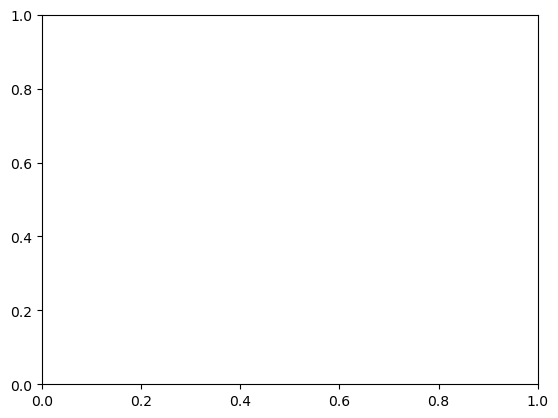

In [ ]:
plt.plot(s, result.get_corr(ell=0, ))